**Import libraries**

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

**Load dataset**

In [66]:
df =pd.read_csv('C:/Users/ss/OneDrive/Desktop/E-commerce Customer Behavior - Sheet1.csv')

In [67]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 27.8 KB


In [5]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


**Data cleaning**

In [6]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='str')

In [57]:
df[df['Satisfaction Level'].isna()]

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level


In [56]:
import warnings 
warnings.filterwarnings('ignore')
df['Satisfaction Level']=df['Satisfaction Level'].fillna('Unknown',inplace=True)

In [ ]:
df[df['Customer ID'].duplicated()]

In [68]:
q1=30
q3=37
iqr=q3-q1

In [69]:
th_max=q3+(iqr*1.5)
th_min=q1-(iqr*1.5)

In [70]:
df[df['Age']<th_min]

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level


In [71]:
df[df['Age']>th_max]

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level


In [ ]:
#Gender distribution 

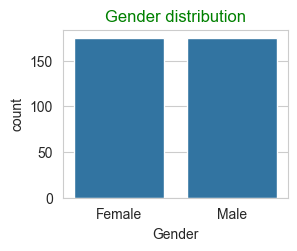

In [59]:
plt.subplot(2,2,1)
sns.countplot(x=df['Gender'])
plt.title('Gender distribution',c='green');

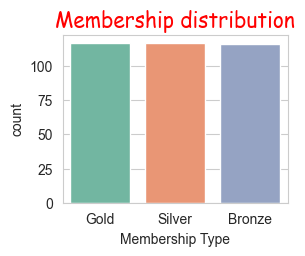

In [62]:
# Which is the higest and lowest  Membership Type
plt.subplot(2,2,1)
sns.countplot(x=df['Membership Type'],palette='Set2')
plt.title('Membership distribution',fontdict={'color':'red','size':15,'family':'cursive'});

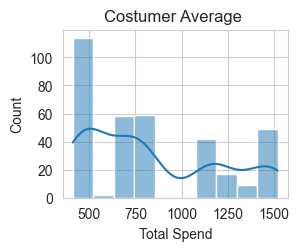

In [64]:
plt.subplot(2,2,1)
sns.histplot(df['Total Spend'],kde=True)
plt.title('Costumer Average ');

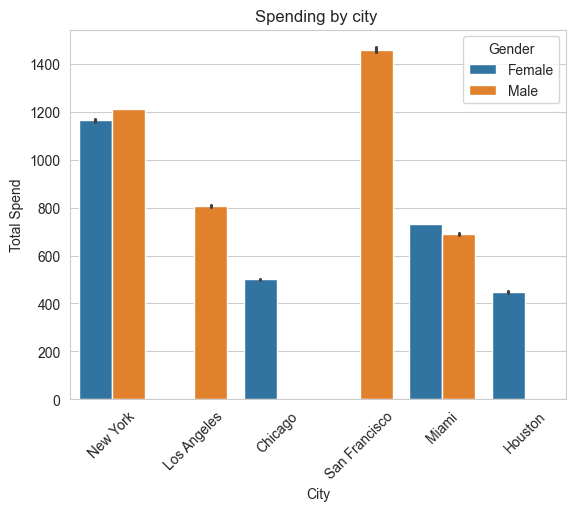

In [65]:
sns.barplot(x=df['City'],y=df['Total Spend'],hue=df['Gender'])
plt.title('Spending by city ')
plt.xticks(rotation=45);

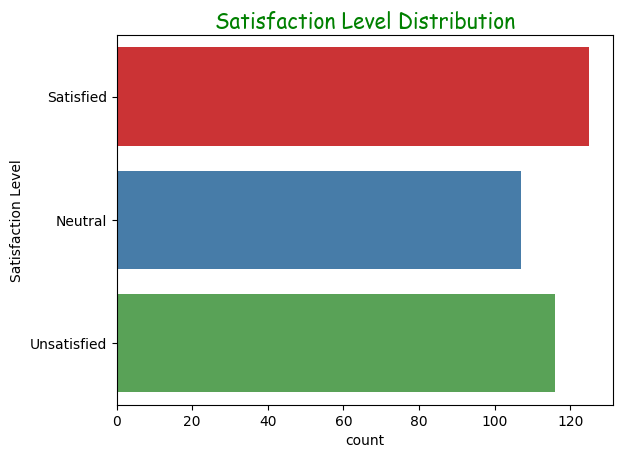

In [20]:
sns.countplot(df['Satisfaction Level'],palette='Set1')
plt.title('Satisfaction Level Distribution',fontdict={'color':'green','size':15,'family':'cursive'});

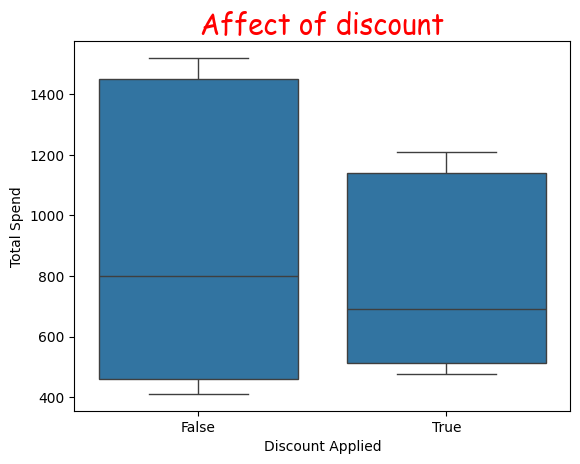

In [27]:
sns.boxplot(x=df['Discount Applied'],y=df['Total Spend'])
plt.title('Affect of discount',fontdict={'color':'red','size':20,'family':'cursive'});

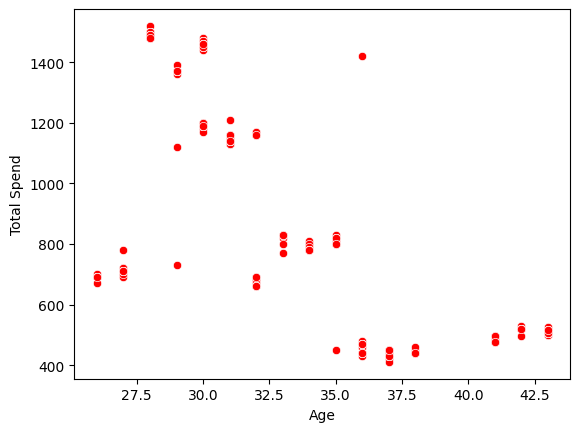

In [39]:
sns.scatterplot(x=df['Age'],y=df['Total Spend'],c='red');

**Dashboard**

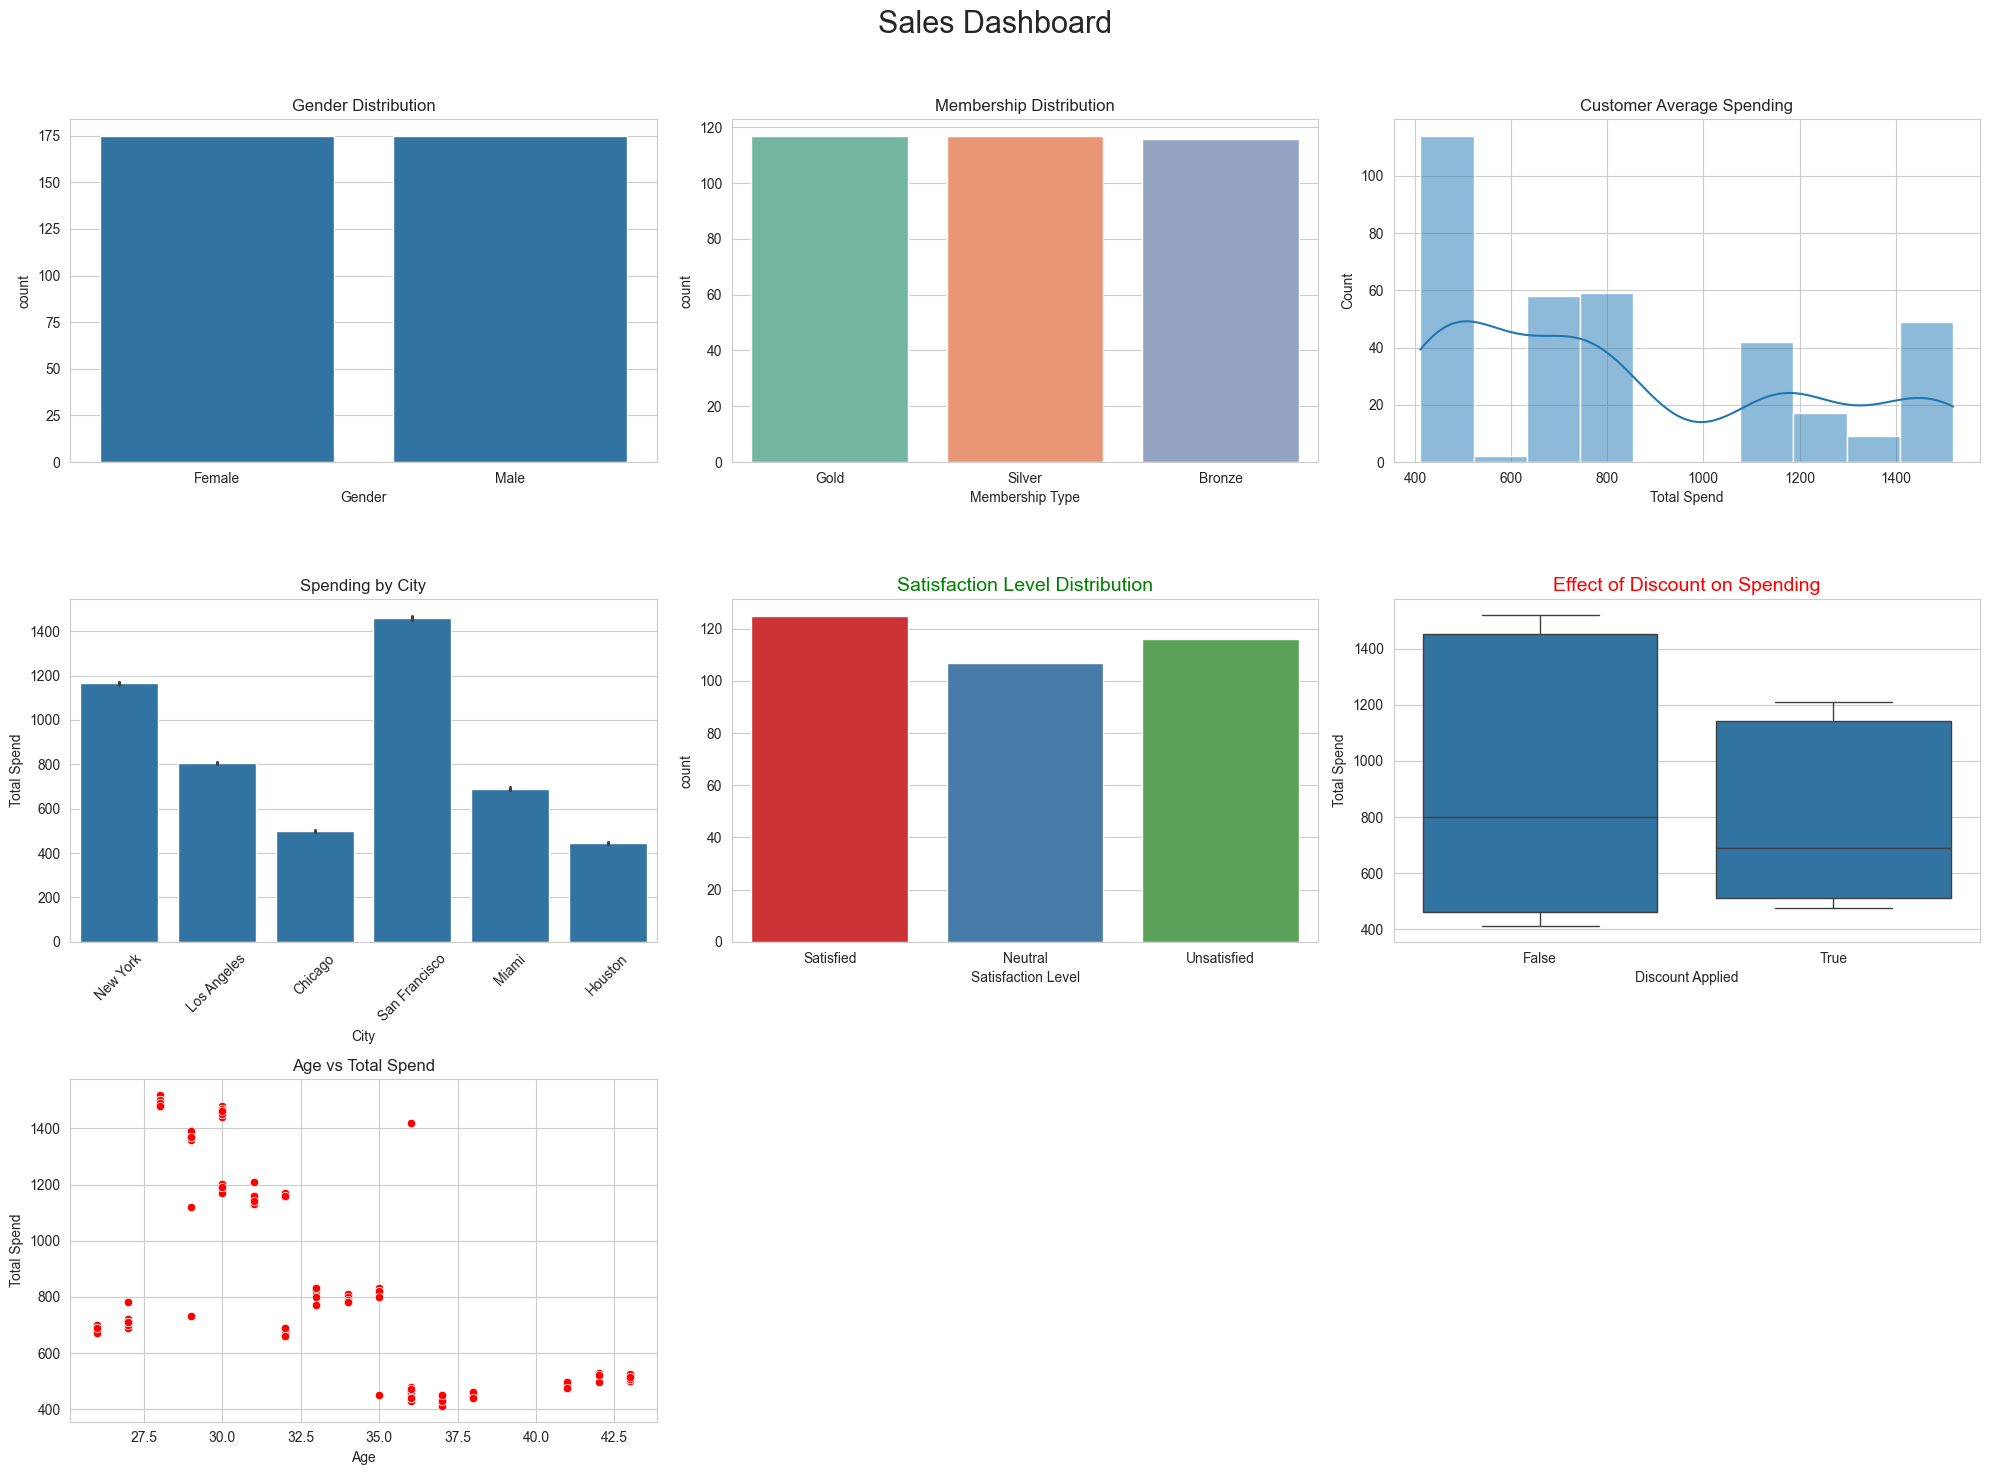

In [52]:
plt.figure(figsize=(20,15))

# 1 Gender
plt.subplot(3,3,1)
sns.countplot(x=df['Gender'])
plt.title('Gender Distribution')

# 2 Membership
plt.subplot(3,3,2)
sns.countplot(x=df['Membership Type'], palette='Set2')
plt.title('Membership Distribution')

# 3 Total Spend
plt.subplot(3,3,3)
sns.histplot(df['Total Spend'], kde=True)
plt.title('Customer Average Spending')

# 4 City Spending
plt.subplot(3,3,4)
sns.barplot(x=df['City'], y=df['Total Spend'])
plt.title('Spending by City')
plt.xticks(rotation=45)

# 5 Satisfaction
plt.subplot(3,3,5)
sns.countplot(x=df['Satisfaction Level'], palette='Set1')
plt.title(
    'Satisfaction Level Distribution',
    fontdict={'color':'green','size':14}
)

# 6 Discount Effect
plt.subplot(3,3,6)
sns.boxplot(x=df['Discount Applied'], y=df['Total Spend'])
plt.title(
    'Effect of Discount on Spending',
    fontdict={'color':'red','size':14}
)

# 7 Age vs Spend
plt.subplot(3,3,7)
sns.scatterplot(x=df['Age'], y=df['Total Spend'], color='red')
plt.title('Age vs Total Spend')

# Main Title
plt.suptitle('Sales Dashboard', fontsize=22)

# Automatic spacing
plt.tight_layout(rect=[0,0,1,0.96]);